In [1]:
import numpy as np
import pickle
from matplotlib import pyplot as plt

from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService


from qiskit.circuit import Parameter, ParameterVector

from hubo_qaoa.utils.parameterise_circuit import parameterise_circuit
from hubo_qaoa.utils.lr_qaoa import get_LR_qaoa_circuit, get_hardware_LR_qaoa_circuit



In [2]:
filename_to_copy_numbers = {
    'test_N4_W6': [2,2,1,1]
}

In [3]:
service = QiskitRuntimeService(name='us_instance')
backend = service.backend(name='ibm_boston')

In [4]:
data_file = '/lustre/scratch127/qpg/jc59/new_hubo_formulation/circuit_depths/results.couplingall.precompute.0.pkl'
with open(data_file, 'rb') as f:
    res = pickle.load(f)

delta_b, delta_g = 0.75, 0.30
p = 1

In [5]:
data_file = '/lustre/scratch127/qpg/jc59/new_hubo_formulation/circuit_depths/results.couplingheavy-hex.precompute.60.pkl'
with open(data_file, 'rb') as f:
    res_hardware = pickle.load(f)

In [6]:
depths_abstract = []
counts_abstract = []
widths = []
for filename in res.keys():
    cost_circuit = parameterise_circuit(res[filename]['rzz']['circuit'], parameter=Parameter('γ'))
    num_qubits = cost_circuit.num_qubits
    phis = ParameterVector('ϕ', num_qubits)

    fixed_qc, circuit = get_LR_qaoa_circuit(p, delta_b, delta_g, num_qubits, cost_circuit, None, phis, True)
    
    widths.append(num_qubits)
    depths_abstract.append(fixed_qc.depth(lambda instr: len(instr.qubits) > 1))
    counts_abstract.append(sum([v for k, v in fixed_qc.count_ops().items() if k in ['rzz', 'cz', 'cx']]))
widths = np.array(widths)    
depths_abstract = np.array(depths_abstract)    
counts_abstract = np.array(counts_abstract)    


14:10:55 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 15
14:10:55 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 121
14:10:55 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 162
14:10:55 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 232
14:10:55 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 253
14:10:55 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 566
14:10:55 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 800
14:10:55 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 268
14:10:55 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 506
14:10:55 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 785
14:10:56 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 952


In [7]:
widths_hardware = []
depths_hardware = []
counts_hardware = []
for filename in res_hardware.keys():
    cost_circuit = res_hardware[filename]['rzz']['circuit']
    if cost_circuit.count_ops().get('u', 0) > 0:
        # Workaround for u gate failing to compile
        from qiskit.circuit.library import UGate
        from qiskit.circuit import Parameter
        from qiskit import QuantumCircuit
        theta = Parameter('t')
        phi = Parameter('p')
        lamda = Parameter('l')
        qc = QuantumCircuit(1)
        qc.p(lamda, 0)
        qc.ry(theta, 0)
        qc.p(phi, 0)
        UGate(theta, phi, lamda).add_decomposition(qc)
    cost_circuit = transpile(cost_circuit, basis_gates=['id', 'rz', 'rz', 'ry', 'cx', 'rzz', 'swap', 'cz', 'p'])
    cost_circuit = parameterise_circuit(cost_circuit, parameter=Parameter('γ'))
    try:
        num_qubits = res[filename]['rzz']['circuit'].num_qubits
    except:
        from hubo_qaoa.utils.gfa_utils import gfa_file_to_graph
        filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'
        _, n, _, T = gfa_file_to_graph(filepath, filename_to_copy_numbers[filename])
        print(filename, n, T)
        num_qubits: int = n*T
        
    phis = ParameterVector('ϕ', num_qubits)
    layout = res_hardware[filename]['rzz']['layout']

    fixed_qc, circuit = get_hardware_LR_qaoa_circuit(p, delta_b, delta_g, num_qubits, cost_circuit, layout, backend, None, phis)    
    widths_hardware.append(num_qubits)
    depths_hardware.append(fixed_qc.depth(lambda instr: len(instr.qubits) > 1))
    counts_hardware.append(sum([v for k, v in fixed_qc.count_ops().items() if k in ['rzz', 'cz', 'cx']]))
    
widths_hardware = np.array(widths_hardware)    
depths_hardware = np.array(depths_hardware)    
counts_hardware = np.array(counts_hardware)     

14:10:57 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 86
14:10:57 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 1078
14:10:58 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 1070
14:10:58 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 1750
14:10:59 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 3681
14:11:01 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 8187
test_N4_W6 3 6
14:11:04 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 2561


In [13]:
filename = 'test_N4_W5'
cost_circuit = res_hardware[filename]['rzz']['circuit']

if cost_circuit.count_ops().get('u', 0) > 0:
    # Workaround for u gate failing to compile
    from qiskit.circuit.library import UGate
    from qiskit.circuit import Parameter
    from qiskit import QuantumCircuit
    theta = Parameter('t')
    phi = Parameter('p')
    lamda = Parameter('l')
    qc = QuantumCircuit(1)
    qc.p(lamda, 0)
    qc.ry(theta, 0)
    qc.p(phi, 0)
    UGate(theta, phi, lamda).add_decomposition(qc)
cost_circuit = transpile(cost_circuit, basis_gates=['id', 'rz', 'rz', 'ry', 'cx', 'rzz', 'swap', 'cz', 'p'])
cost_circuit = parameterise_circuit(cost_circuit, parameter=Parameter('γ'))
try:
    num_qubits = res[filename]['rzz']['circuit'].num_qubits
except:
    from hubo_qaoa.utils.gfa_utils import gfa_file_to_graph
    filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'
    _, n, _, T = gfa_file_to_graph(filepath, filename_to_copy_numbers[filename])
    print(filename, n, T)
    num_qubits: int = n*T
    
phis = ParameterVector('ϕ', num_qubits)
layout = res_hardware[filename]['rzz']['layout']

fixed_qc, circuit = get_hardware_LR_qaoa_circuit(p, delta_b, delta_g, num_qubits, cost_circuit, layout, backend, None, phis)
    

14:11:36 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 1849


In [14]:
fixed_qc.count_ops()

OrderedDict([('sx', 2293),
             ('rz', 1605),
             ('cz', 1219),
             ('delay', 923),
             ('measure', 15),
             ('x', 7)])

In [16]:
sum([v for k, v in fixed_qc.count_ops().items() if k in ['sx', 'rz', 'cz', 'x']])

5124

In [11]:
indices = np.argsort(widths)
print('filename qubits depths count')
for index in indices:
    print(np.array(list(res.keys()))[index], widths[index], depths_abstract[index], counts_abstract[index])

filename qubits depths count
test_N2_W2 4 10 10
test_N7_W2 8 239 291
test_N8_W2 8 256 307
trivial 9 108 140
test_N7_W3 12 546 678
test_N3_W4 12 149 212
test_N8_W3 12 483 612
test_N4_W5 15 218 327
test_N7_W4 16 764 1094
test_N8_W5 20 754 1225
test_N8_W6 24 918 1660


In [12]:
indices = np.argsort(widths_hardware)
print('filename qubits depths count total_ops')
for index in indices:
    print(np.array(list(res_hardware.keys()))[index], widths_hardware[index], depths_hardware[index], counts_hardware[index])

filename qubits depths count total_ops
test_N2_W2 4 19 24
test_N7_W2 8 1219 1610
trivial 9 338 515
test_N3_W4 12 320 697
test_N7_W3 12 2869 4670
test_N4_W5 15 570 1178
test_N4_W6 18 840 1714


In [ ]:
grid = np.linspace(min(widths[0], widths_hardware[0]), max(widths[-1], widths_hardware[-1]), 100)
p_depth = np.polynomial.Polynomial.fit(widths, depths_abstract, 1)
p_depth_hardware = np.polynomial.Polynomial.fit(widths_hardware, depths_hardware, 1)
p_count = np.polynomial.Polynomial.fit(widths, counts_abstract, 2)
p_count_hardware = np.polynomial.Polynomial.fit(widths_hardware, counts_hardware, 2)


Text(0.5, 1.0, '2-qubit gate depth and count for HUBO-QAOA')

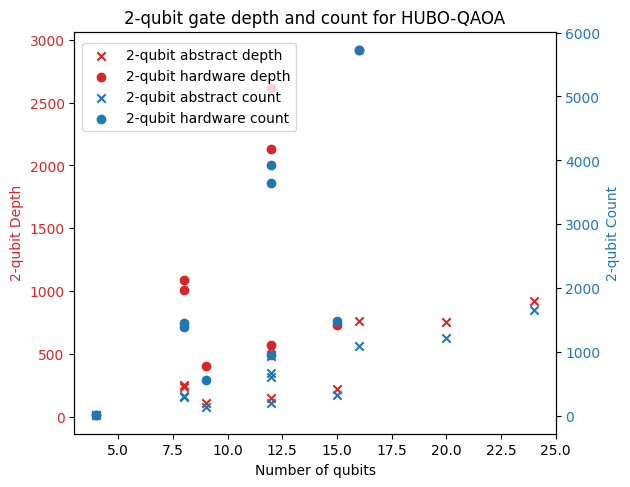

In [ ]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.scatter(widths, depths_abstract, color=color, marker='x', label='2-qubit abstract depth')
ax1.scatter(widths_hardware, depths_hardware, color=color, label='2-qubit hardware depth')


# ax1.plot(grid, p_depth(grid), color=color)
# ax1.plot(grid, p_depth_hardware(grid), color=color)


ax1.set_xlabel('Number of qubits')
ax1.set_ylabel('2-qubit Depth', color=color)
# ax1.set_ylim(0, depths_hardware[-1] * 1.1)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.scatter(widths, counts_abstract, color=color, marker='x', label='2-qubit abstract count')
ax2.scatter(widths_hardware, counts_hardware, color=color, label='2-qubit hardware count')

# ax2.plot(grid, p_count(grid), color=color)
# ax2.plot(grid, p_count_hardware(grid), color=color)

ax2.set_ylabel('2-qubit Count', color=color)
# ax2.set_ylim(0, counts_hardware[-1] * 1.1)
ax2.tick_params(axis='y', labelcolor=color)

fig.legend(loc=(0.13,0.73))
fig.tight_layout()
ax1.set_title('2-qubit gate depth and count for HUBO-QAOA')